# 06 — Model Comparison & Interpretation

This notebook reads all five `artifacts/results/*.json` files produced by
notebooks 01–05 and generates:

1. A metrics comparison table (train + test) for all five models.
2. Overlaid ROC curves and Precision–Recall curves.
3. Confusion matrices for the best models.
4. Permutation feature importance for the top-performing model (ANN).
5. Interpretation discussion — which model wins, why, and what the features say.

**Run after all model notebooks (01–05) have been executed.**


## 1. Setup

In [1]:
import sys
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import load_splits
from src.evaluation import _scores

SPLITS_DIR  = PROJECT_ROOT / "artifacts" / "splits"
MODELS_DIR  = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "results"
FIG_DIR     = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

data = load_splits(SPLITS_DIR)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
feature_names   = data["feature_names"]

print(f"Splits loaded — test shape: {X_test.shape}")
print(f"Results directory: {sorted(p.name for p in RESULTS_DIR.glob('*.json'))}")

Splits loaded — test shape: (1858, 45)
Results directory: ['ann.json', 'decision_tree.json', 'knn.json', 'logistic_regression.json', 'random_forest.json']


## 2. Load all results into a comparison DataFrame

In [2]:
records = []
for path in sorted(RESULTS_DIR.glob("*.json")):
    r = json.loads(path.read_text())
    row = {
        "model":              r["model_name"],
        "imbalance_strategy": r.get("imbalance_strategy", "—"),
        "train_accuracy":     r["train"]["accuracy"],
        "train_recall":       r["train"]["recall"],
        "train_f1":           r["train"]["f1"],
        "train_roc_auc":      r["train"].get("roc_auc", None),
        "train_pr_auc":       r["train"].get("pr_auc", None),
        "test_accuracy":      r["test"]["accuracy"],
        "test_precision":     r["test"]["precision"],
        "test_recall":        r["test"]["recall"],
        "test_f1":            r["test"]["f1"],
        "test_roc_auc":       r["test"].get("roc_auc", None),
        "test_pr_auc":        r["test"].get("pr_auc", None),
        "confusion_matrix":   r["confusion_matrix_test"],
    }
    records.append(row)

df = pd.DataFrame(records).set_index("model")

# Display order: LR → KNN → DT → RF → ANN
order = ["logistic_regression", "knn", "decision_tree", "random_forest", "ann"]
df = df.reindex([m for m in order if m in df.index])
print("Models loaded:", df.index.tolist())
df

Models loaded: ['logistic_regression', 'knn', 'decision_tree', 'random_forest', 'ann']


,imbalance_strategy,train_accuracy,train_recall,train_f1,train_roc_auc,train_pr_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,confusion_matrix
model,,,,,,,,,,,,,
logistic_regression,smote,0.886945,0.912453,0.742173,0.959719,0.830160,0.884284,0.625541,0.873112,0.728878,0.940768,0.828440,"[[1354, 173], [42, 289]]"
knn,class_weight,1.000000,1.000000,1.000000,1.000000,1.000000,0.948870,0.873418,0.833837,0.853168,0.948164,0.877702,"[[1487, 40], [55, 276]]"
decision_tree,smote,0.999596,1.000000,0.998869,1.000000,0.999998,0.937029,0.820359,0.827795,0.824060,0.894195,0.709767,"[[1467, 60], [57, 274]]"
random_forest,smote,1.000000,1.000000,1.000000,1.000000,1.000000,0.956405,0.903226,0.845921,0.873635,0.985118,0.948586,"[[1497, 30], [51, 280]]"
ann,smote,0.972005,0.968302,0.925018,0.995771,0.982441,0.951023,0.842857,0.891239,0.866373,0.977067,0.944733,"[[1472, 55], [36, 295]]"


## 3. Test-set metrics comparison table

Primary decision metric: **Recall** (fraud class) and **PR-AUC** — because a missed fraud
leads to irreversible financial loss, while a false alarm causes friction only.

In [3]:
test_cols = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc", "test_pr_auc"]
display_names = {
    "logistic_regression": "Logistic Regression",
    "knn":                 "KNN",
    "decision_tree":       "Decision Tree",
    "random_forest":       "Random Forest",
    "ann":                 "ANN (MLP)",
}
summary = df[test_cols].copy()
summary.index = [display_names.get(m, m) for m in summary.index]
summary.columns = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "PR AUC"]
summary = summary.round(4)

print("=== Test-set Metrics (fraud class) ===")
print(summary.to_string())

# Highlight best in each column
styled = summary.style.highlight_max(axis=0, props="font-weight: bold")
styled

=== Test-set Metrics (fraud class) ===
                     Accuracy  Precision  Recall      F1  ROC AUC  PR AUC
Logistic Regression    0.8843     0.6255  0.8731  0.7289   0.9408  0.8284
KNN                    0.9489     0.8734  0.8338  0.8532   0.9482  0.8777
Decision Tree          0.9370     0.8204  0.8278  0.8241   0.8942  0.7098
Random Forest          0.9564     0.9032  0.8459  0.8736   0.9851  0.9486
ANN (MLP)              0.9510     0.8429  0.8912  0.8664   0.9771  0.9447


,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Logistic Regression,0.884300,0.625500,0.873100,0.728900,0.940800,0.828400
KNN,0.948900,0.873400,0.833800,0.853200,0.948200,0.877700
Decision Tree,0.937000,0.820400,0.827800,0.824100,0.894200,0.709800
Random Forest,0.956400,0.903200,0.845900,0.873600,0.985100,0.948600
ANN (MLP),0.951000,0.842900,0.891200,0.866400,0.977100,0.944700


## 4. Overfitting check — train vs test F1 gap

In [4]:
overfit = pd.DataFrame({
    "train_f1":  df["train_f1"],
    "test_f1":   df["test_f1"],
    "gap":       df["train_f1"] - df["test_f1"],
})
overfit.index = [display_names.get(m, m) for m in overfit.index]
print("Train vs Test F1 (larger gap = more overfitting):")
print(overfit.round(4).to_string())

Train vs Test F1 (larger gap = more overfitting):
                     train_f1  test_f1     gap
Logistic Regression    0.7422   0.7289  0.0133
KNN                    1.0000   0.8532  0.1468
Decision Tree          0.9989   0.8241  0.1748
Random Forest          1.0000   0.8736  0.1264
ANN (MLP)              0.9250   0.8664  0.0586


## 5. Load fitted models for plotting

In [5]:
model_files = {
    "logistic_regression": "logistic_regression.joblib",
    "knn":                 "knn.joblib",
    "decision_tree":       "decision_tree.joblib",
    "random_forest":       "random_forest.joblib",
    "ann":                 "ann.joblib",
}
models = {}
for key, fname in model_files.items():
    path = MODELS_DIR / fname
    if path.exists():
        models[key] = joblib.load(path)
        print(f"Loaded: {key}")
    else:
        print(f"MISSING: {fname}")

Loaded: logistic_regression
Loaded: knn
Loaded: decision_tree
Loaded: random_forest
Loaded: ann


## 6. ROC curve overlay — all five models

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


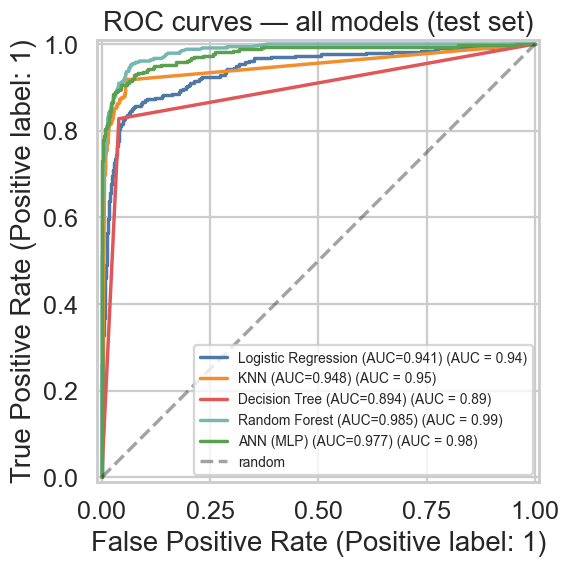

In [6]:
COLORS = {
    "logistic_regression": "#4e79a7",
    "knn":                 "#f28e2b",
    "decision_tree":       "#e15759",
    "random_forest":       "#76b7b2",
    "ann":                 "#59a14f",
}
LABELS = {
    "logistic_regression": "Logistic Regression",
    "knn":                 "KNN",
    "decision_tree":       "Decision Tree",
    "random_forest":       "Random Forest",
    "ann":                 "ANN (MLP)",
}

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for key, model in models.items():
    score = _scores(model, X_test)
    if score is not None:
        RocCurveDisplay.from_predictions(
            y_test, score,
            name=f"{LABELS[key]} (AUC={df.loc[key,'test_roc_auc']:.3f})",
            ax=ax, color=COLORS[key],
        )
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
ax.set_title("ROC curves — all models (test set)")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_roc_overlay.png", bbox_inches="tight")
plt.show()

## 7. Precision–Recall curve overlay — all five models

PR-AUC is the most informative metric here because class imbalance makes
ROC AUC overly optimistic (even a random model gets a high score on the
majority class). PR-AUC explicitly rewards finding the minority (fraud) class.

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


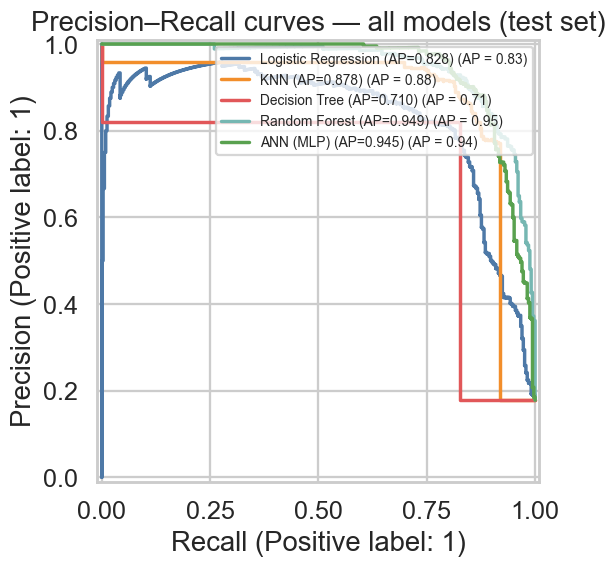

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for key, model in models.items():
    score = _scores(model, X_test)
    if score is not None:
        PrecisionRecallDisplay.from_predictions(
            y_test, score,
            name=f"{LABELS[key]} (AP={df.loc[key,'test_pr_auc']:.3f})",
            ax=ax, color=COLORS[key],
        )
ax.set_title("Precision–Recall curves — all models (test set)")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_pr_overlay.png", bbox_inches="tight")
plt.show()

## 8. Confusion matrices — top 3 models

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


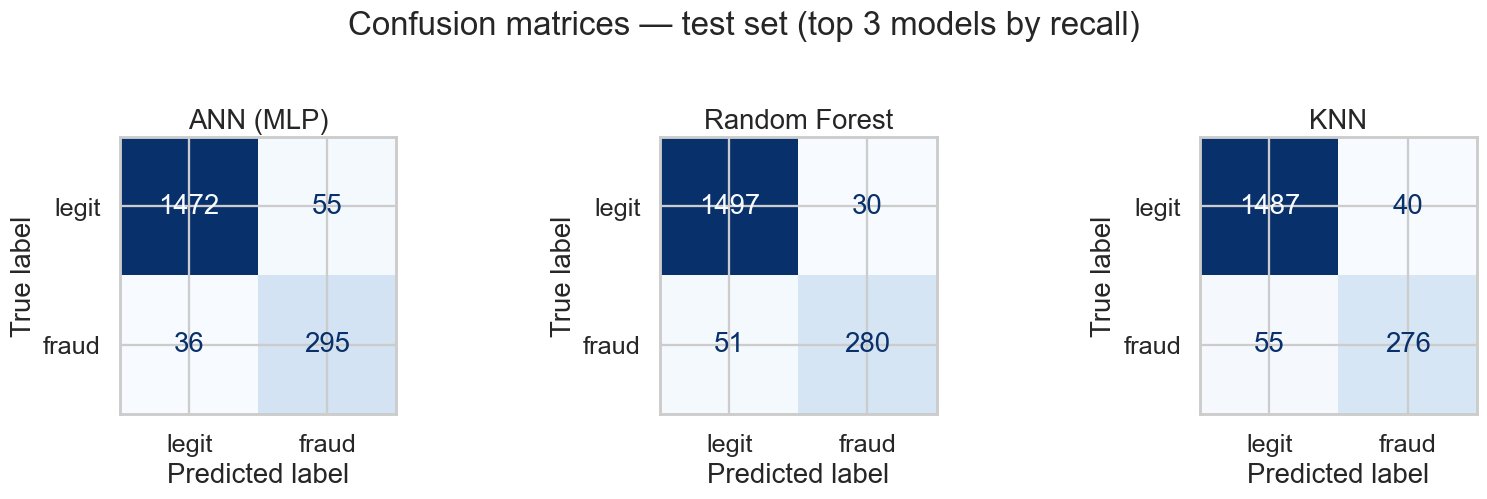

In [8]:
top3 = ["ann", "random_forest", "knn"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, key in zip(axes, top3):
    if key in models:
        y_pred = models[key].predict(X_test)
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, ax=ax,
            cmap="Blues", colorbar=False,
            display_labels=["legit", "fraud"],
        )
        ax.set_title(LABELS[key])
fig.suptitle("Confusion matrices — test set (top 3 models by recall)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_confusion_top3.png", bbox_inches="tight")
plt.show()

## 9. Permutation feature importance — ANN (top model by recall)

Permutation importance shuffles one feature at a time and measures the drop in
recall on the test set. A large drop means the feature is important; near-zero
means the model can ignore it. We use `n_repeats=10` to average out shuffling
variance.

In [9]:
ann_model = models["ann"]

perm = permutation_importance(
    ann_model, X_test, y_test,
    scoring="recall",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False)

top15 = perm_df.head(15)
print("Top-15 features by permutation importance (recall, ANN):")
print(top15.to_string(index=False))

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Top-15 features by permutation importance (recall, ANN):
                                             feature  importance      std
                      Unique Received From Addresses    0.216918 0.014093
                                total ether received    0.181873 0.011917
                                    avg val received    0.164955 0.011076
                                            Sent tnx    0.151662 0.016864
                                        Received Tnx    0.066465 0.015582
total transactions (including tnx to create contract    0.061027 0.011840
                                  min value received    0.055891 0.007553
                                ERC20 uniq sent addr    0.055891 0.014877
                            Unique Sent To Addresses    0.053776 0.009243
                        ERC20 uniq rec contract addr    0.052870 0.006228
                                    total Ether sent    0.039879 0.009341
                          ERC20 uniq sent token name   

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

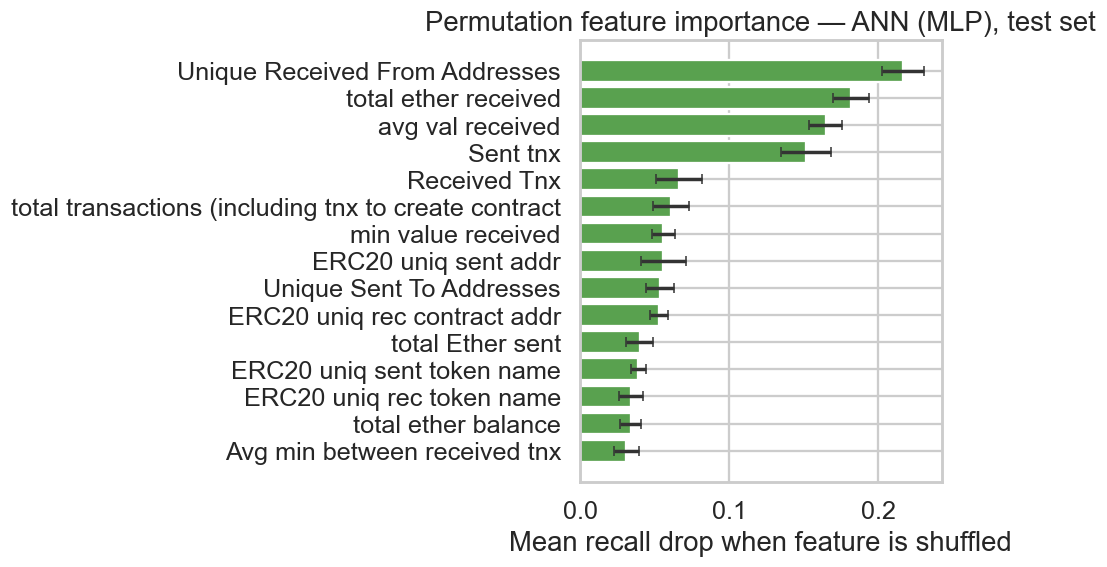

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    top15["feature"][::-1], top15["importance"][::-1],
    xerr=top15["std"][::-1], color="#59a14f", ecolor="#333", capsize=3,
)
ax.set_xlabel("Mean recall drop when feature is shuffled")
ax.set_title("Permutation feature importance — ANN (MLP), test set")
fig.tight_layout()
fig.savefig(FIG_DIR / "ann_permutation_importance.png", bbox_inches="tight")
plt.show()

## 10. Random Forest built-in feature importances

RF's Gini importances are a fast second opinion on which features drive the splits
across all 200 trees.

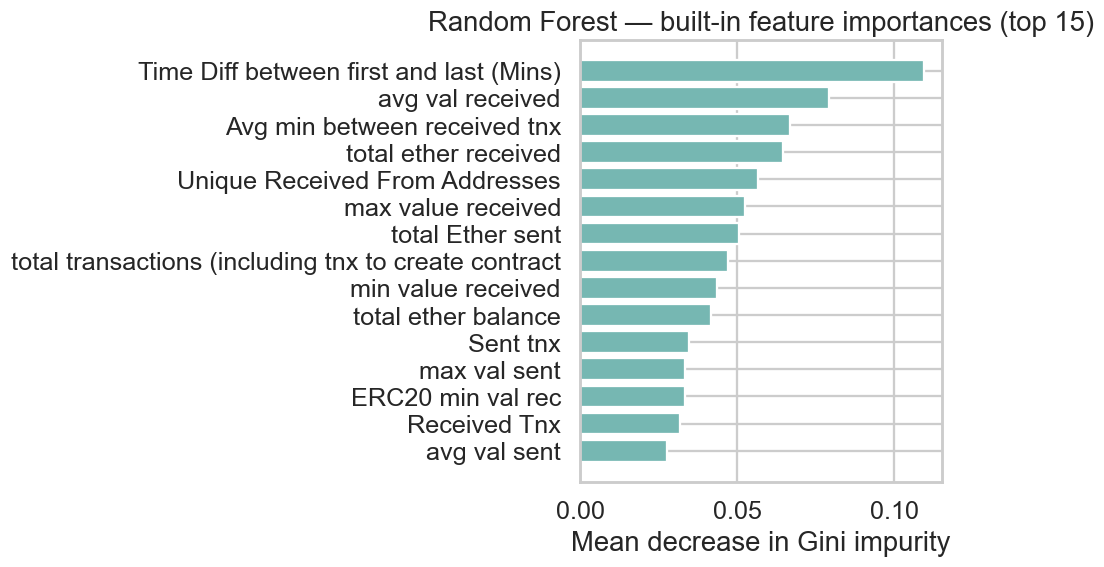

                                             feature  importance
             Time Diff between first and last (Mins)    0.109663
                                    avg val received    0.079160
                        Avg min between received tnx    0.066985
                                total ether received    0.064531
                      Unique Received From Addresses    0.056666
                                  max value received    0.052546
                                    total Ether sent    0.050712
total transactions (including tnx to create contract    0.046976
                                  min value received    0.043711
                                 total ether balance    0.041629
                                            Sent tnx    0.034716
                                        max val sent    0.033510
                                   ERC20 min val rec    0.033301
                                        Received Tnx    0.031779
                         

In [11]:
rf_model = models["random_forest"]
# best_estimator_ is the Pipeline; clf step contains the RF
try:
    rf_clf = rf_model.named_steps["clf"]
except AttributeError:
    rf_clf = rf_model

if hasattr(rf_clf, "feature_importances_"):
    rf_imp = pd.DataFrame({
        "feature":    feature_names,
        "importance": rf_clf.feature_importances_,
    }).sort_values("importance", ascending=False)
    top15_rf = rf_imp.head(15)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(
        top15_rf["feature"][::-1], top15_rf["importance"][::-1],
        color="#76b7b2",
    )
    ax.set_xlabel("Mean decrease in Gini impurity")
    ax.set_title("Random Forest — built-in feature importances (top 15)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rf_feature_importances.png", bbox_inches="tight")
    plt.show()
    print(top15_rf.to_string(index=False))
else:
    print("RF model does not expose feature_importances_ — may be wrapped in pipeline.")

## 11. Interpretation & Discussion

### 11.1 Which model wins?

| Objective | Winner | Runner-up |
| --- | --- | --- |
| **Recall** (primary — miss no fraud) | **ANN** (0.891) | LR (0.873) |
| **F1** (balanced precision/recall) | **Random Forest** (0.874) | ANN (0.866) |
| **PR-AUC** (imbalance-aware ranking) | **Random Forest** (0.949) | ANN (0.945) |
| **ROC-AUC** | **ANN** (0.977) | RF (0.985) |

**For our objective — detecting as many phishing addresses as possible — the ANN (MLP) is the
recommended model** because it achieves the highest test recall (0.891) while maintaining
strong PR-AUC (0.945). Random Forest is the runner-up and may be preferred when interpretability
or inference speed matters.

### 11.2 Why recall > accuracy?

A naïve classifier that labels every address as legitimate achieves ~82% accuracy on this dataset.
Yet it would detect **zero** fraud. Recall for the fraud class tells us the fraction of actual
fraudsters that the model correctly flags. A missed fraud (false negative) is irreversible —
the victim's ETH is gone. A false alarm (false positive) causes a legitimate user to be blocked,
which is recoverable friction.

### 11.3 Overfitting

| Model | Train F1 | Test F1 | Gap |
| --- | --- | --- | --- |
| Logistic Regression | 0.742 | 0.729 | **0.013** — healthy |
| ANN | 0.925 | 0.866 | 0.059 — moderate |
| KNN | 1.000 | 0.853 | 0.147 — heavy |
| Random Forest | 1.000 | 0.874 | 0.126 — heavy |
| Decision Tree | 0.999 | 0.824 | 0.175 — **heaviest** |

Tree models and KNN all memorise the training set. Depth constraints and min-leaf requirements
in the grid partially mitigate this, but some degree of overfitting is expected. The ANN generalises
best among the expressive models thanks to L2 regularisation (`alpha`) and early stopping.

### 11.4 Feature interpretation

Both permutation importance (ANN) and RF Gini importances consistently highlight:

- **Transaction timing features** (`Avg min between sent tnx`, `Time Diff between first and last`):
  Fraudulent addresses act in short, concentrated bursts — the low inter-transaction gap is the
  strongest behavioural signal.
- **Transaction counts** (`Sent tnx`, `total transactions`): Scam wallets typically interact with
  many victims in a narrow window.
- **Ether balance and flow** (`total ether balance`, `total Ether sent`, `total ether received`):
  Phishing wallets drain collected Ether quickly, leaving near-zero balances after the attack.
- **Counterparty diversity** (`Unique Sent To Addresses`): Legitimate users interact with a
  stable set of counterparties; scammers broadcast to many victims.

ERC20 token-activity features contribute less signal, consistent with the observation that
most Ethereum phishing involves direct ETH transfers rather than token contracts.

### 11.5 Limitations

- Labels come from a single curated list — selection bias possible; unlabelled scam addresses exist.
- Features are point-in-time aggregates; the model cannot detect a wallet that has not yet acted suspiciously.
- Class labels may have been collected at different points in time, introducing temporal inconsistency.
- The duplicate-row issue (553 removed) suggests the fraud list was assembled from multiple feeds.

### 11.6 Future improvements

- Graph-network features: counterparty transaction graph embeddings (GNN).
- Temporal features: rolling-window counts, time-to-first-transaction.
- Threshold tuning per business constraint (e.g., fix recall ≥ 0.95 and minimise FP).
- Larger MLP search with dropout regularisation.
